# 01 · Análisis exploratorio de datos (EDA)
**Proyecto:** Análisis de sentimiento en redes sociales para una agencia de marketing.

**Insight de este pipeline:** clasificar automáticamente el *tono* (sentimiento) de cada post a partir de su texto, y complementarlo descubriendo los *temas* de conversación con un modelo no supervisado.

Este notebook explora el dataset, evalúa su calidad y **documenta qué columnas se usan y cuáles se descartan, con su justificación**.

In [13]:
# === Setup reproducible (Google Colab) ===
import sys, os, subprocess, glob
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

hits = glob.glob("/content/drive/MyDrive/**/src/config.py", recursive=True)
if not hits:
    raise FileNotFoundError(
        "No se encontro src/config.py en tu Drive. Verifica que subiste "
        "la carpeta completa del proyecto (con la carpeta src/ y sus .py)."
    )
root = Path(hits[0]).parent.parent
os.environ["PROJECT_ROOT"] = str(root)
sys.path.insert(0, str(root / "src"))

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"],
               check=False)

from config import set_global_seed, ensure_dirs, SEED
set_global_seed(SEED)   # fija todas las semillas
ensure_dirs()           # crea carpetas de salida
print(f"Entorno listo. Raiz del proyecto: {root} | SEED={SEED}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno listo. Raiz del proyecto: /content/drive/MyDrive/Programación Ev2/Adolfo | SEED=42


## 1. Carga del dataset

In [14]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from data_preprocessing import load_dataset, basic_quality_report

df = load_dataset()
print('Dimensiones:', df.shape)
df.head(3)

Dimensiones: (12000, 28)


,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4


## 2. Calidad de los datos
Revisamos tipos, valores nulos y cardinalidad de cada columna.

In [15]:
rep = basic_quality_report(df)
rep

,dtype,n_nulos,pct_nulos,n_unicos
mentions,object,3941,32.84,225
post_id,object,0,0.00,12000
day_of_week,object,0,0.00,7
timestamp,object,0,0.00,11997
platform,object,0,0.00,5
user_id,object,0,0.00,12000
language,object,0,0.00,10
location,object,0,0.00,33
text_content,object,0,0.00,11997
hashtags,object,0,0.00,4490


**Lectura:** el dataset está muy limpio. La única columna con nulos es `mentions` (~33%), que en realidad significan *"el post no menciona a nadie"*, no datos perdidos. No hay filas duplicadas.

In [16]:
print('Duplicados:', df.duplicated().sum())

Duplicados: 0


## 3. Distribución del objetivo: `sentiment_label`
Es la variable que queremos predecir. Vemos si las clases están balanceadas.

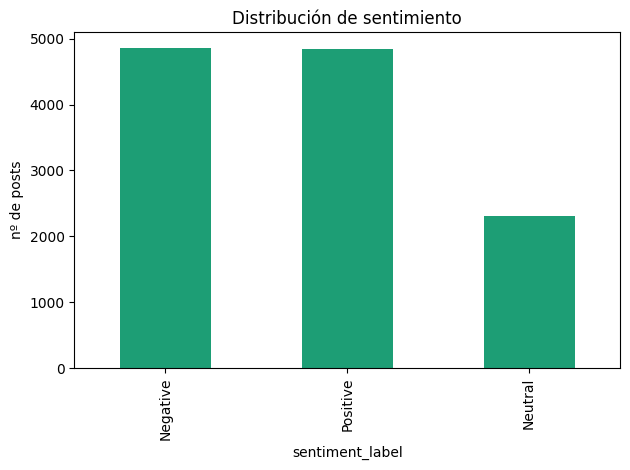

sentiment_label
Negative    40.4
Positive    40.3
Neutral     19.2
Name: proportion, dtype: float64


In [17]:
ax = df['sentiment_label'].value_counts().plot(kind='bar', color='#1D9E75')
ax.set_title('Distribución de sentimiento'); ax.set_ylabel('nº de posts')
plt.tight_layout(); plt.show()
print((df['sentiment_label'].value_counts(normalize=True)*100).round(1))

### 3.1 Codificación de las clases (qué significan 0, 1, 2)
El modelo no trabaja con texto en la etiqueta, sino con números. scikit-learn ordena las clases **alfabéticamente**, por lo que la correspondencia es:

| Código | Etiqueta |
|---|---|
| **0** | Negative |
| **1** | Neutral |
| **2** | Positive |

Esta codificación es la que aparece en la matriz de confusión (notebook 03).

Codificación de clases:
  0 -> Negative
  1 -> Neutral
  2 -> Positive


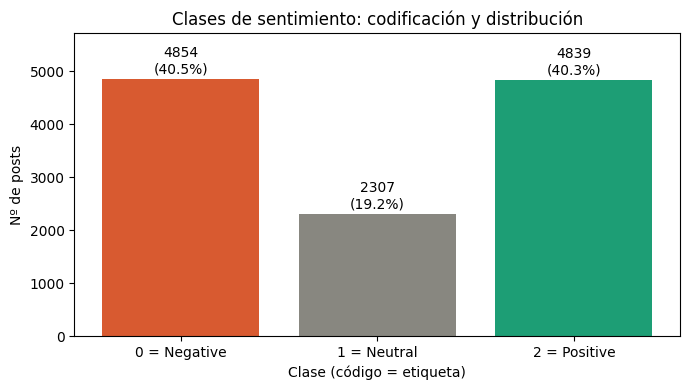

In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder().fit(df['sentiment_label'])
mapa = {i: c for i, c in enumerate(le.classes_)}
print('Codificación de clases:')
for i, c in mapa.items():
    print(f'  {i} -> {c}')

# Distribución con la codificación visible
import matplotlib.pyplot as plt
colores = {'Negative':'#D85A30','Neutral':'#888780','Positive':'#1D9E75'}
conteo = [ (df['sentiment_label']==mapa[i]).sum() for i in range(3) ]
fig, ax = plt.subplots(figsize=(7,4))
barras = ax.bar([f'{i} = {mapa[i]}' for i in range(3)], conteo,
                color=[colores[mapa[i]] for i in range(3)])
ax.set_title('Clases de sentimiento: codificación y distribución')
ax.set_ylabel('Nº de posts'); ax.set_xlabel('Clase (código = etiqueta)')
for b, c in zip(barras, conteo):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+50,
            f'{c}\n({c/len(df)*100:.1f}%)', ha='center', va='bottom')
ax.set_ylim(0, max(conteo)*1.18)
from config import PLOTS_DIR
plt.tight_layout(); plt.savefig(PLOTS_DIR / '01_clases.png', dpi=130); plt.show()

## 3.2 Ingeniería de características: ¿conviene crear features manuales?
El texto se vectoriza con **TF-IDF** (eso ya es ingeniería de características automática). La pregunta es si **añadir features manuales** —largo del post, nº de palabras, signos de exclamación/interrogación, mayúsculas— mejora el modelo. Lo evaluamos comparando tres escenarios contra el azar (≈0.34).

In [19]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from scipy.sparse import hstack, csr_matrix

def feat_eng(s):
    return pd.DataFrame({
        'len_chars': s.str.len(),
        'n_words': s.str.split().str.len(),
        'n_exclaim': s.str.count('!'),
        'n_question': s.str.count(r'\?'),
        'n_upper': s.apply(lambda x: sum(1 for c in str(x) if c.isupper())),
        'avg_word_len': s.apply(lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0),
    })

Xtxt = df['text_content'].fillna(''); ysent = df['sentiment_label']
Xeng = feat_eng(Xtxt)
Xtr_t, Xte_t, Xtr_e, Xte_e, ytr, yte = train_test_split(
    Xtxt, Xeng, ysent, test_size=0.2, random_state=SEED, stratify=ysent)

vec = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
Xtr_tf = vec.fit_transform(Xtr_t); Xte_tf = vec.transform(Xte_t)
f1_text = f1_score(yte, LogisticRegression(max_iter=1000, random_state=SEED).fit(Xtr_tf, ytr).predict(Xte_tf), average='macro')

sc = StandardScaler()
Xtr_es = csr_matrix(sc.fit_transform(Xtr_e)); Xte_es = csr_matrix(sc.transform(Xte_e))
f1_comb = f1_score(yte, LogisticRegression(max_iter=1000, random_state=SEED).fit(hstack([Xtr_tf, Xtr_es]), ytr).predict(hstack([Xte_tf, Xte_es])), average='macro')
f1_eng = f1_score(yte, LogisticRegression(max_iter=1000, random_state=SEED).fit(Xtr_es, ytr).predict(Xte_es), average='macro')

print(f'Solo texto (TF-IDF):        F1 = {f1_text:.4f}')
print(f'Texto + features manuales:  F1 = {f1_comb:.4f}')
print(f'Solo features manuales:     F1 = {f1_eng:.4f}')
print(f'Ganancia de features manuales: {(f1_comb-f1_text)*100:+.2f} puntos')

Solo texto (TF-IDF):        F1 = 0.9366
Texto + features manuales:  F1 = 0.9361
Solo features manuales:     F1 = 0.3480
Ganancia de features manuales: -0.06 puntos


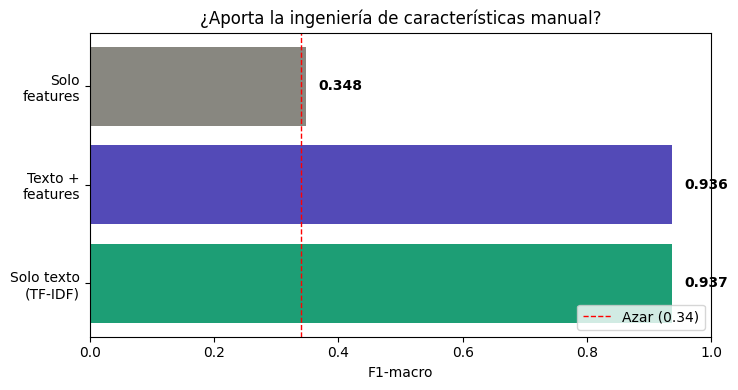

In [20]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7.5,4))
enf = ['Solo texto\n(TF-IDF)', 'Texto +\nfeatures', 'Solo\nfeatures']
vals = [f1_text, f1_comb, f1_eng]
ax.barh(enf, vals, color=['#1D9E75', '#534AB7', '#888780'])
ax.axvline(0.34, ls='--', color='red', lw=1, label='Azar (0.34)')
ax.set_xlim(0,1); ax.set_xlabel('F1-macro')
ax.set_title('¿Aporta la ingeniería de características manual?')
for i, v in enumerate(vals):
    ax.text(v+0.02, i, f'{v:.3f}', va='center', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(PLOTS_DIR / '02_feature_eng.png', dpi=130); plt.show()

/tmp/ipykernel_1214/4258257245.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[mapa[i][:3] for i in range(3)],
/tmp/ipykernel_1214/4258257245.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[mapa[i][:3] for i in range(3)],
/tmp/ipykernel_1214/4258257245.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[mapa[i][:3] for i in range(3)],


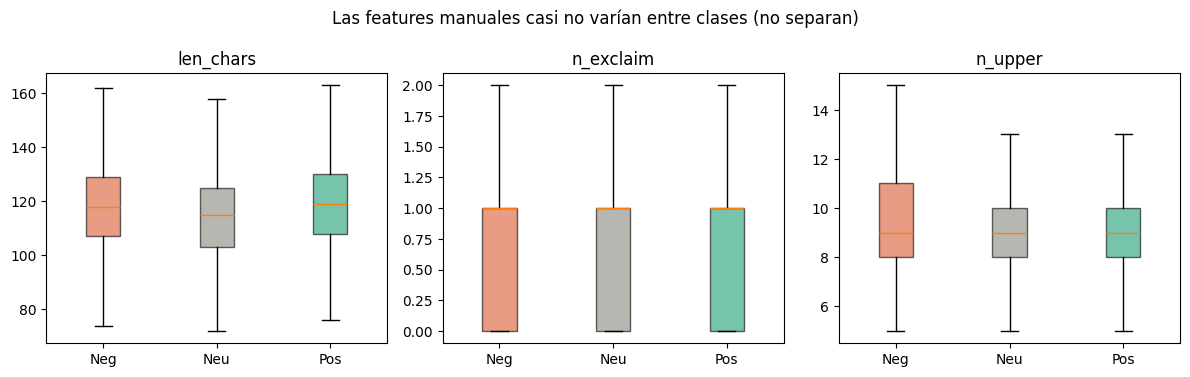

In [21]:
# ¿Por qué no aportan? Porque son casi idénticas entre clases.
fig, axes = plt.subplots(1, 3, figsize=(12,3.8))
for ax, feat in zip(axes, ['len_chars','n_exclaim','n_upper']):
    data = [Xeng[feat][ysent==mapa[i]] for i in range(3)]
    bp = ax.boxplot(data, labels=[mapa[i][:3] for i in range(3)],
                    patch_artist=True, showfliers=False)
    for patch, i in zip(bp['boxes'], range(3)):
        patch.set_facecolor(colores[mapa[i]]); patch.set_alpha(0.6)
    ax.set_title(feat)
fig.suptitle('Las features manuales casi no varían entre clases (no separan)')
plt.tight_layout(); plt.savefig(PLOTS_DIR / '03_features_no_separan.png', dpi=130); plt.show()

**Conclusión (decisión de ingeniería de características):** añadir features manuales **no mejora** el modelo (varía ±0.01, ruido) y por sí solas quedan al nivel del azar (~0.35). Los boxplots explican por qué: largo, signos y mayúsculas son casi idénticos entre clases. **Toda la señal está en las palabras**, que el TF-IDF ya captura. Por eso se trabaja con el texto vectorizado y no se añade ingeniería manual: decisión evaluada con evidencia, no por omisión.

## 4. ¿Por qué clasificamos desde el TEXTO y no desde `sentiment_score`?
`sentiment_label` se **deriva directamente** de `sentiment_score` por umbrales. Usar el score como feature sería *fuga de datos* (data leakage): el modelo acertaría ~100% sin aprender nada útil para posts nuevos.

In [22]:
# Evidencia del leakage: el score determina la etiqueta por rangos.
df.groupby('sentiment_label')['sentiment_score'].agg(['min','max']).round(3)

,min,max
sentiment_label,,
Negative,-1.0,-0.2
Neutral,-0.2,0.2
Positive,0.2,1.0


Por eso la **única feature de entrada será `text_content`**. Una agencia, ante un post nuevo, solo tiene el texto; el modelo debe funcionar en ese escenario real.

## 5. Columnas descartadas y su justificación
Decisión central del EDA. Cada columna fuera del modelado tiene un motivo documentado en `src/config.py` (`DROPPED_COLUMNS`) y resumido aquí.

In [23]:
from config import DROPPED_COLUMNS, TEXT_COLUMN, TARGET_COLUMN
print(f'FEATURE usada : {TEXT_COLUMN}')
print(f'OBJETIVO      : {TARGET_COLUMN}')
print(f'DESCARTADAS   : {len(DROPPED_COLUMNS)} columnas\n')
drop_df = pd.DataFrame(
    [(c, r) for c, r in DROPPED_COLUMNS.items()],
    columns=['columna', 'motivo_descarte'])
drop_df

FEATURE usada : text_content
OBJETIVO      : sentiment_label
DESCARTADAS   : 24 columnas



,columna,motivo_descarte
0,post_id,Identificador unico (12000/12000). No aporta s...
1,user_id,Identificador unico por fila. Mismo problema q...
2,sentiment_score,FUGA DE DATOS: sentiment_label se deriva de es...
3,timestamp,Fecha sin patron temporal util para clasificar...
4,language,Metadato del usuario; el texto real esta en in...
5,location,Alta cardinalidad (33) sin relacion con el sen...
6,brand_name,Identidad de marca; introduce sesgo y no es se...
7,product_name,"Alta cardinalidad (70). Memoriza productos, no..."
8,campaign_name,Alta cardinalidad (23); nombre de campana no d...
9,hashtags,Etiquetas tematicas (#Food); ruido para clasif...


Las razones se agrupan en cuatro tipos:
1. **Fuga de datos** — `sentiment_score` (deriva la etiqueta), `emotion_type`.
2. **Identificadores únicos** — `post_id`, `user_id`: memorizan, no generalizan.
3. **Métricas de resultado (post-publicación)** — `likes_count`, `shares_count`, `comments_count`, `impressions`, `engagement_rate`: son consecuencia, no causa del tono.
4. **Metadatos sin señal de tono** — `language`, `location`, `brand_name`, `product_name`, `campaign_name`, `hashtags`, `mentions`, `keywords`, `day_of_week`, `timestamp`, `campaign_phase`, `buzz_change_rate`, `user_*`.

Nota: `topic_category` no entra como feature de tono, pero se reserva para **cruzar** con los clusters del notebook 02 (tema × tono).

## 6. Verificación: el texto sí contiene señal de sentimiento
Antes de modelar, confirmamos que las palabras distinguen las clases.

In [24]:
for lab in ['Positive','Negative','Neutral']:
    print(f'\n--- {lab} ---')
    for t in df[df.sentiment_label==lab]['text_content'].head(2):
        print('  ', t[:90])


--- Positive ---
   Just tried the Chromebook from Google. Best purchase ever. #Food Really interested in hear
   Just tried the Corolla from Toyota. Absolutely loving it. #Health, #Travel Really interest

--- Negative ---
   Just saw an ad for Microsoft Surface Laptop during the SpringBlast2025. Not worth the mone
   What's your opinion about Nike's Epic React?  #Promo, #Food, #Trending Really interested i

--- Neutral ---
   Just unboxed my new Halo Band from Amazon. It's okay. Thrilled #ProductLaunch, #Health Cur
   Has anyone else experienced customer service with Coca-Cola's Coca-Cola Vanilla? As expect


**Conclusión del EDA:** datos limpios y balanceados; clasificamos el sentimiento desde `text_content`; descartamos 24 columnas por leakage, identificadores, métricas de resultado o ausencia de señal. Pasamos al modelado (02).